# Electrical Time Series Data Classification with FCN

## Prepare Notebook

In [16]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while p.name != "tinyml-timeseries" and p.parent != p:
    p = p.parent

REPO_ROOT = p
sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])

REPO_ROOT: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries
sys.path[0]: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries


## Imports

In [17]:
import os
import src.data.io as data_io
import numpy as np
from src.deployment.export import (
    export_tflite_int8,
    tflite_to_c_header
)
from src.utils.visualization import plot_training_history
from src.data.split import stratified_split
from src.evaluation.metrics import (
    evaluate_classification,
    plot_confusion_matrix
)
from src.data.preprocessing import (
    clean_train_test,
    minmax_fit_transform_per_feature,
    one_hot_encode_labels,
)
from src.deployment.inference import (
    load_tflite_model, 
    run_tflite_inference
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, 
    Conv1D, 
    BatchNormalization, 
    ReLU, 
    GlobalAveragePooling1D, 
    Dense
)
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ReduceLROnPlateau, 
    ModelCheckpoint
)
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    classification_report
)


## Data Preparation

### Data Loading

In [ ]:
ed_data, ed_labels = data_io.load_data_sliding(pkl_rel_path="data/data_sliding.pkl")

X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    ed_data, ed_labels, test_size=0.2, val_size=0.1
)

X_train, X_val, X_test = clean_train_test(X_train, X_val, X_test)
X_train_final, X_val, X_test, scalers = minmax_fit_transform_per_feature(X_train, X_val, X_test)

y_train_final, y_val, y_test, num_classes = one_hot_encode_labels(y_train, y_val, y_test)


print("\nFinal shapes:")
print("Train", X_train_final.shape)
print("Val", X_val.shape)
print("Test", X_test.shape)
print("Classes:", num_classes)

Cycle-boundary temporal split successful
  Train: 29108 (70.0%) | {0: 6260, 1: 657, 2: 1771, 3: 1285, 4: 8942, 5: 6783, 6: 1788, 7: 1622}
  Val:   4158   (10.0%)  | {0: 894, 1: 94, 2: 254, 3: 183, 4: 1277, 5: 969, 6: 256, 7: 231}
  Test:  8315  (20.0%) | {0: 1789, 1: 187, 2: 506, 3: 366, 4: 2555, 5: 1938, 6: 511, 7: 463}
NaN & Inf values cleaned.
Data normalization complete (MinMax per feature).
One-hot encoding complete. Classes: 8

Final shapes:
Train (29108, 60, 5)
Val (4158, 60, 5)
Test (8315, 60, 5)
Classes: 8


### Dataset Size

In [19]:
train_size_bytes = X_train_final.nbytes
print(f"Train Set Size in MB: {train_size_bytes / (1024 * 1024):.2f} MB")

Train Set Size in MB: 66.62 MB


## FCN Model

### Building

In [20]:
def build_fcn(input_shape=X_train_final.shape[1:], num_classes=num_classes):
    inputs = Input(shape=input_shape)

    x = Conv1D(filters=128, kernel_size=8, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters=256, kernel_size=5, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters=128, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling1D()(x)  # FCN’in temel özelliği GAP kullanımı

    outputs = Dense(num_classes, activation='softmax')(x)  # Yalnızca çıkış katmanı Dense olur

    model = Model(inputs, outputs)

    return model

fcn_model = build_fcn()

fcn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

fcn_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 60, 5)]           0         
                                                                 
 conv1d_3 (Conv1D)           (None, 60, 128)           5248      
                                                                 
 batch_normalization_3 (Bat  (None, 60, 128)           512       
 chNormalization)                                                
                                                                 
 re_lu_3 (ReLU)              (None, 60, 128)           0         
                                                                 
 conv1d_4 (Conv1D)           (None, 60, 256)           164096    
                                                                 
 batch_normalization_4 (Bat  (None, 60, 256)           1024      
 chNormalization)                                          

### Training

In [21]:
def train_fcn(model, X_train, y_train, X_val, y_val,
              epochs=30, batch_size=32, save_best_model=True):
    callbacks = []

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    callbacks.append(early_stopping)

    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    callbacks.append(lr_scheduler)

    if save_best_model:
        model_checkpoint = ModelCheckpoint("../../models/standard/best_fcn_model.h5", save_best_only=True, monitor="val_loss")
        callbacks.append(model_checkpoint)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history

history = train_fcn(fcn_model,
                    X_train_final, y_train_final,
                    X_val, y_val,
                    epochs=50,
                    batch_size=32,
                    save_best_model=True)

Epoch 1/50
910/910 [==============================] - 12s 12ms/step - loss: 0.3456 - accuracy: 0.8742 - val_loss: 0.6256 - val_accuracy: 0.8379 - lr: 0.0010
Epoch 2/50
 16/910 [..............................] - ETA: 10s - loss: 0.2908 - accuracy: 0.8945

/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


910/910 [==============================] - 11s 13ms/step - loss: 0.2437 - accuracy: 0.9058 - val_loss: 0.4501 - val_accuracy: 0.8776 - lr: 0.0010
Epoch 3/50
910/910 [==============================] - 12s 13ms/step - loss: 0.2136 - accuracy: 0.9183 - val_loss: 0.5447 - val_accuracy: 0.8725 - lr: 0.0010
Epoch 4/50
910/910 [==============================] - 12s 14ms/step - loss: 0.1856 - accuracy: 0.9281 - val_loss: 0.6542 - val_accuracy: 0.8759 - lr: 0.0010
Epoch 5/50
910/910 [==============================] - 12s 13ms/step - loss: 0.1728 - accuracy: 0.9334 - val_loss: 0.4401 - val_accuracy: 0.9117 - lr: 0.0010
Epoch 6/50
910/910 [==============================] - 13s 14ms/step - loss: 0.1596 - accuracy: 0.9381 - val_loss: 0.6372 - val_accuracy: 0.8793 - lr: 0.0010
Epoch 7/50
910/910 [==============================] - 13s 15ms/step - loss: 0.1456 - accuracy: 0.9427 - val_loss: 0.4425 - val_accuracy: 0.8951 - lr: 0.0010
Epoch 8/50
909/910 [============================>.] - ETA: 0s - loss:

## Evaluation

### Training Performance

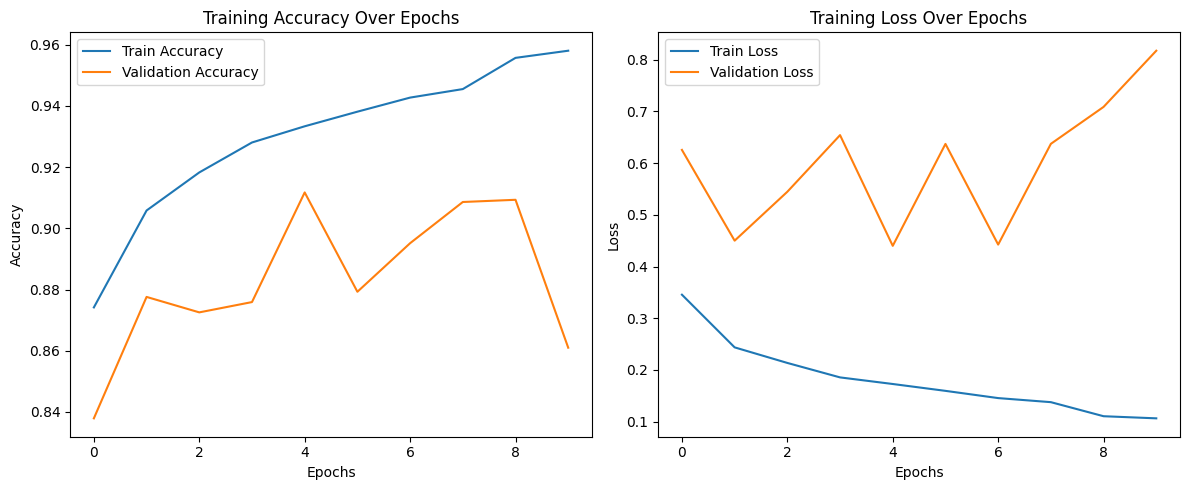

In [22]:
plot_training_history(history)

### Classification Metrics

260/260 [==============================] - 1s 3ms/step

Test Accuracy: 0.7887

Classification Report:
              precision    recall  f1-score   support

           0     0.9094    0.4936    0.6399      1789
           1     0.3529    0.8342    0.4960       187
           2     0.8564    0.6245    0.7223       506
           3     0.8727    0.1311    0.2280       366
           4     0.9161    0.9358    0.9258      2555
           5     0.9923    1.0000    0.9961      1938
           6     0.3500    0.7515    0.4776       511
           7     0.5403    0.9546    0.6901       463

    accuracy                         0.7887      8315
   macro avg     0.7238    0.7157    0.6470      8315
weighted avg     0.8585    0.7887    0.7873      8315



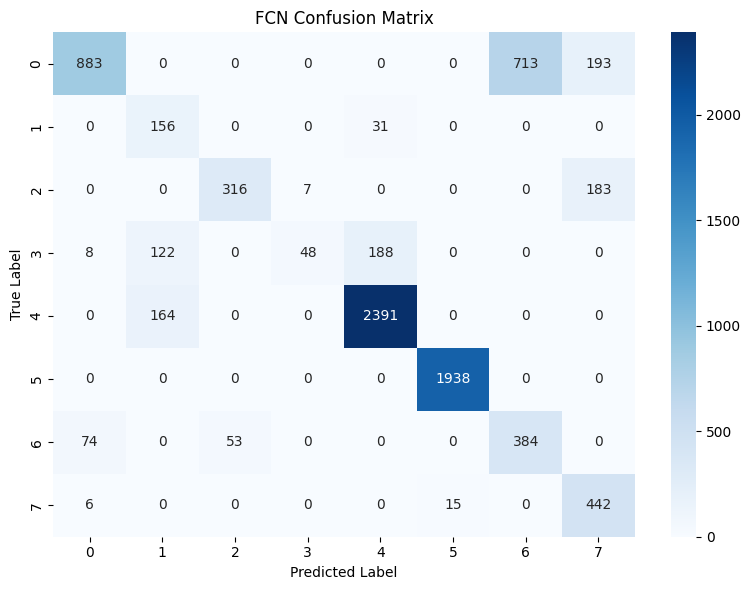

In [31]:
accuracy, report, y_pred = evaluate_classification(
    fcn_model,
    X_test,
    y_test
)

y_true = y_test.argmax(axis=1)

cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="FCN Confusion Matrix"
)

### Model Saving and Size Check

In [24]:
fcn_model.save("../../models/fcn_model.h5")

model_size = os.path.getsize("../../models/fcn_model.h5") / (1024 * 1024)
print(f"Real Model Size: {model_size:.2f} MB")

Real Model Size: 3.16 MB


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## TinyML Performance

### TF Lite Conversion

In [25]:
TFLITE_MODEL_PATH = "../../models/fcn_model_quantized.tflite"

export_tflite_int8(
    model=fcn_model,
    X_calibration=X_train,
    save_path=TFLITE_MODEL_PATH,
    n_samples=200
)

INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpi4eee7bc/assets


INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpi4eee7bc/assets
/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-03 00:01:29.039126: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 00:01:29.039137: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Quantized model saved: ../../models/fcn_model_quantized.tflite (283.80 KB)


2026-03-03 00:01:29.039239: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpi4eee7bc
2026-03-03 00:01:29.040390: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 00:01:29.040396: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpi4eee7bc
2026-03-03 00:01:29.043627: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-03-03 00:01:29.077734: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpi4eee7bc
2026-03-03 00:01:29.086963: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 47723 microseconds.
Summary on the non-converted ops:
---------------------------------
 * Accepted dialects: tfl, builtin, func
 * N

b'\x1c\x00\x00\x00TFL3\x14\x00 \x00\x1c\x00\x18\x00\x14\x00\x10\x00\x0c\x00\x00\x00\x08\x00\x04\x00\x14\x00\x00\x00\x1c\x00\x00\x00\x80\x00\x00\x00\xd8\x00\x00\x00\xd0"\x04\x00\xe0"\x04\x00xn\x04\x00\x03\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00\xf6\xda\xfb\xff\x0c\x00\x00\x00\x1c\x00\x00\x008\x00\x00\x00\x0f\x00\x00\x00serving_default\x00\x01\x00\x00\x00\x04\x00\x00\x00\x9c\xff\xff\xff\x18\x00\x00\x00\x04\x00\x00\x00\x07\x00\x00\x00dense_1\x00\x01\x00\x00\x00\x04\x00\x00\x00\xe6\xdc\xfb\xff\x04\x00\x00\x00\x07\x00\x00\x00input_2\x00\x02\x00\x00\x004\x00\x00\x00\x04\x00\x00\x00\xdc\xff\xff\xff\x1b\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00CONVERSION_METADATA\x00\x08\x00\x0c\x00\x08\x00\x04\x00\x08\x00\x00\x00\x1a\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00min_runtime_version\x00\x1c\x00\x00\x00\xf4!\x04\x00\xec!\x04\x00\xd8!\x04\x00\xbc!\x04\x00\xa0!\x04\x00\x8c!\x04\x00\\!\x04\x00L\x1d\x04\x00<\x1b\x04\x00,\x9b\x02\x00\x1c\x97\x02\x00\x0c\x17\x00\x00\xfc\x14\x00\x00\xec\x00\x00\x00

### Evaluation

In [26]:
interpreter = load_tflite_model(TFLITE_MODEL_PATH)

y_pred = run_tflite_inference(interpreter, X_test)
y_true = np.argmax(y_test, axis=1)

print("TFLite model prediction completed.")

TFLite model prediction completed.


### Test Classification Report

In [27]:
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

classification_rep = classification_report(y_true, y_pred, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_rep)

Test Accuracy: 0.2152
Precision: 0.0463
Recall: 0.2152
F1-score: 0.0762

Classification Report:
              precision    recall  f1-score   support

           0     0.2152    1.0000    0.3541      1789
           1     0.0000    0.0000    0.0000       187
           2     0.0000    0.0000    0.0000       506
           3     0.0000    0.0000    0.0000       366
           4     0.0000    0.0000    0.0000      2555
           5     0.0000    0.0000    0.0000      1938
           6     0.0000    0.0000    0.0000       511
           7     0.0000    0.0000    0.0000       463

    accuracy                         0.2152      8315
   macro avg     0.0269    0.1250    0.0443      8315
weighted avg     0.0463    0.2152    0.0762      8315



/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

### Confusion Matrix

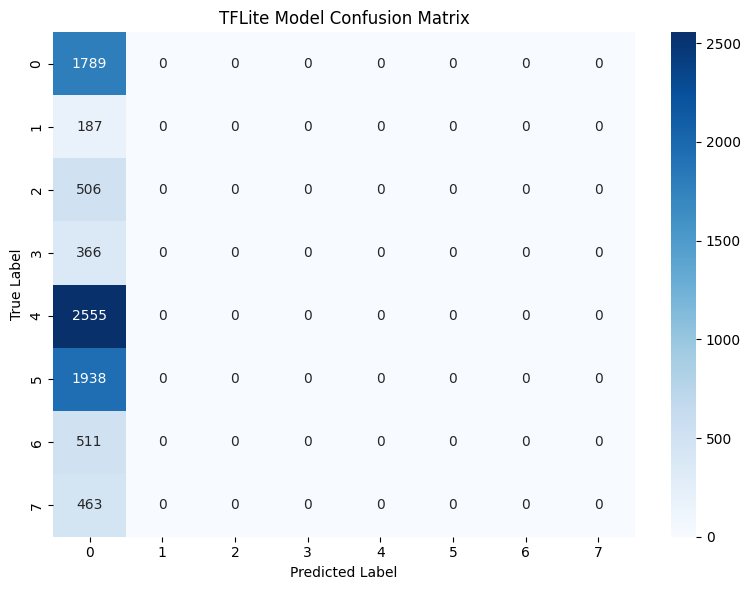

In [28]:
cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TFLite Model Confusion Matrix"
)

### Model Size

In [29]:
tflite_model_path = "../../models/tinyml/fcn_model_quantized.tflite"

tflite_model_size = os.path.getsize(tflite_model_path)

print(f"TFLite Model Size: {tflite_model_size / 1024:.2f} KB")

TFLite Model Size: 283.66 KB


### ESP32 Compatible Header File Creation

In [30]:
tflite_to_c_header(
    "../../models/tinyml/fcn_model_quantized.tflite",
    var_name="fcn_model"
)

C header created: ../../models/tinyml/fcn_model_quantized.h
Size: 283.66 KB


PosixPath('../../models/tinyml/fcn_model_quantized.h')